In [10]:
import pandas as pd

df = pd.read_csv('/content/creditcard.csv')
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
df = pd.read_csv('/content/creditcard.csv')

# Display first 5 rows
print(df.head())

# Dataset Information
print("\nDataset Shape:", df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [16]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64



Class Distribution:
Class
0.0    121960
1.0       249
Name: count, dtype: int64


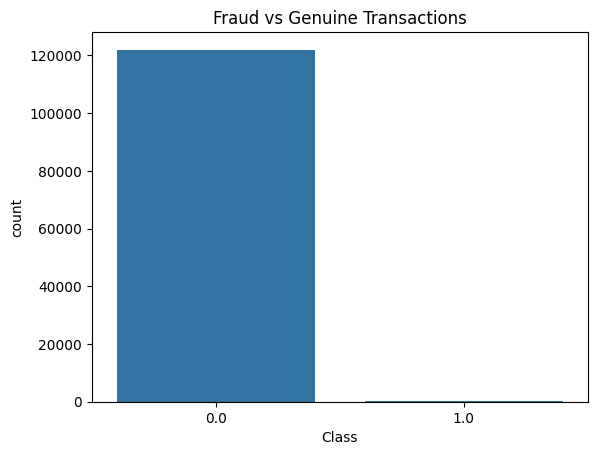

In [17]:
print("\nClass Distribution:")
print(df['Class'].value_counts())

# 0 -> Genuine Transaction
# 1 -> Fraudulent Transaction

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

In [18]:
X = df.drop('Class', axis=1)
y = df['Class']


In [20]:
Scaler = StandardScaler()

X_scaled = Scaler.fit_transform(X)

In [22]:
# Create a boolean mask for non-NaN values in y
not_nan_mask = y.notna()

# Filter X_scaled and y to remove rows where y is NaN
X_scaled_cleaned = X_scaled[not_nan_mask.values]
y_cleaned = y[not_nan_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_cleaned, # Use the cleaned X_scaled
    y_cleaned,        # Use the cleaned y
    test_size=0.2,
    random_state=42,
    stratify=y_cleaned # Stratify with the cleaned y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (97767, 30)
Testing Data Shape: (24442, 30)



LOGISTIC REGRESSION

Accuracy: 0.9987726045331806
Precision: 0.7631578947368421
Recall: 0.58
F1 Score: 0.6590909090909091

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     24392
         1.0       0.76      0.58      0.66        50

    accuracy                           1.00     24442
   macro avg       0.88      0.79      0.83     24442
weighted avg       1.00      1.00      1.00     24442



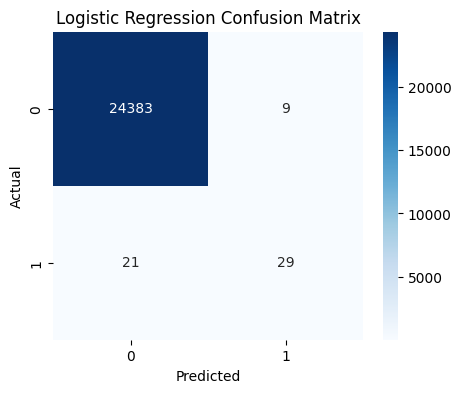

In [23]:
print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

lr_model = LogisticRegression(max_iter=1000)

# Train Model
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



NAIVE BAYES

Accuracy: 0.9785205793306604
Precision: 0.08260105448154657
Recall: 0.94
F1 Score: 0.1518578352180937

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     24392
         1.0       0.08      0.94      0.15        50

    accuracy                           0.98     24442
   macro avg       0.54      0.96      0.57     24442
weighted avg       1.00      0.98      0.99     24442



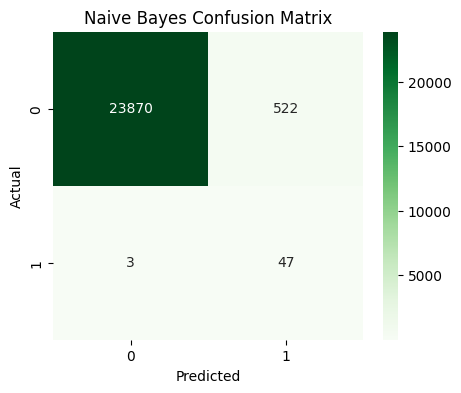

In [24]:
print("\n==============================")
print("NAIVE BAYES")
print("==============================")

nb_model = GaussianNB()

# Train Model
nb_model.fit(X_train, y_train)

# Prediction
y_pred_nb = nb_model.predict(X_test)

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression  0.998773   0.763158    0.58  0.659091
1          Naive Bayes  0.978521   0.082601    0.94  0.151858


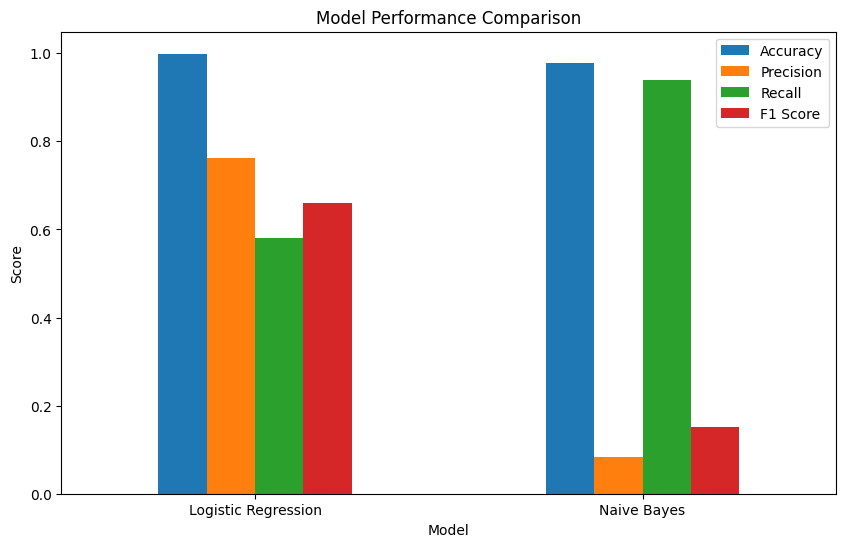

In [25]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb)
    ]
})

print("\n==============================")
print("MODEL COMPARISON")
print("==============================")

print(results)

# Plot Comparison

results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [26]:
import joblib

joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(nb_model, 'naive_bayes_model.pkl')

print("\nModels saved successfully!")



Models saved successfully!
